# Vector Algebra and Kinematics

This notebook covers fundamental vector operations and kinematics using SymPy's mechanics package.

## Topics Covered:
- Vector representation and operations
- Position, velocity, and acceleration vectors
- Coordinate systems and transformations
- Relative motion

In [1]:
import sympy as sp
from sympy.physics.mechanics import *
import sympy.physics.vector as spv
import sympy.physics.mechanics as me
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import IPython display for proper LaTeX formatting
from IPython.display import Math

# Initialize symbols
sp.init_printing()

# Enable dot notation printing for dynamicsymbols
from sympy.physics.vector.printing import init_vprinting
init_vprinting(use_latex='mathjax')



In [2]:
N = spv.ReferenceFrame("N", latexs=(
    fr'\; {{}}^\mathcal {{N}} \hat \imath',
    fr'\;{{}}^\mathcal {{N}} \hat \jmath',
    fr'\: {{}}^\mathcal {{N}} \hat {{k}}'
))

N.x + N.y + N.z

n_x + n_y + n_z

## Basic Vector Operations

In [3]:
# Define unit vectors
i = N.x
j = N.y
k = N.z

# Create position vectors
r1 = 3*i + 4*j + 5*k
r2 = 2*i - 1*j + 3*k

print("Vector r1:")
display(r1)
print("\nVector r2:")
display(r2)

# Vector operations
r_sum = r1 + r2
r_diff = r1 - r2
r_dot = r1.dot(r2)
r_cross = r1.cross(r2)
r1_mag = r1.magnitude()

print(f"\nSum: {r_sum}")
print(f"Difference: {r_diff}")
print(f"Dot product: {r_dot}")
print(f"Cross product: {r_cross}")
print(f"Magnitude of r1: {r1_mag}")

Vector r1:


3 n_x + 4 n_y + 5 n_z


Vector r2:


2 n_x-n_y + 3 n_z


Sum: 5*N.x + 3*N.y + 8*N.z
Difference: N.x + 5*N.y + 2*N.z
Dot product: 17
Cross product: 17*N.x + N.y - 11*N.z
Magnitude of r1: 5*sqrt(2)


# Week 1 Kinematics

## Kinematics: Position, Velocity, and Acceleration

In [4]:

# Create dynamicsymbols (functions of time with dot notation)
x, y, z = dynamicsymbols('x y z')

# Position vector as a function of time
r = x*N.x + y*N.y + z*N.z

# Time derivatives using dt() method (dot notation)
v = r.dt(N)  # First time derivative (ẋ, ẏ, ż)
a = v.dt(N)  # Second time derivative (ẍ, ÿ, z̈)

print("Position vector:")
display(r)
print("\nVelocity vector (using dot notation):")
display(v)
print("\nAcceleration vector (using dot notation):")
display(a)

# Show individual component derivatives with dot notation
print("\n--- Individual Component Derivatives ---")
# For dynamicsymbols, we can access the time variable internally
print("dx/dt =", x.diff(dynamicsymbols._t))  # Shows as ẋ
print("d²x/dt² =", x.diff(dynamicsymbols._t, 2))  # Shows as ẍ

# Compare with traditional diff method
print("\n--- Comparison of Methods ---")
v_diff = r.diff(dynamicsymbols._t, N)
a_diff = v_diff.diff(dynamicsymbols._t, N)
print("Using r.dt(N):", v)
print("Using r.diff(t, N):", v_diff)
print("Both methods give equivalent results")

Position vector:


x n_x + y n_y + z n_z


Velocity vector (using dot notation):


ẋ n_x + ẏ n_y + ż n_z


Acceleration vector (using dot notation):


ẍ n_x + ÿ n_y + z̈ n_z


--- Individual Component Derivatives ---
dx/dt = Derivative(x(t), t)
d²x/dt² = Derivative(x(t), (t, 2))

--- Comparison of Methods ---
Using r.dt(N): Derivative(x(t), t)*N.x + Derivative(y(t), t)*N.y + Derivative(z(t), t)*N.z
Using r.diff(t, N): Derivative(x(t), t)*N.x + Derivative(y(t), t)*N.y + Derivative(z(t), t)*N.z
Both methods give equivalent results


## Example: Projectile Motion

In [5]:
# Define constants for projectile motion
g = sp.symbols('g', positive=True)  # gravitational acceleration
v0 = sp.symbols('v0', positive=True)  # initial velocity magnitude
theta = sp.symbols('theta', real=True)  # launch angle

# Create dynamicsymbols for position components
x_proj, y_proj = dynamicsymbols('x_proj y_proj')

# Initial conditions (constants)
x0, y0 = 0, 0
vx0 = v0*sp.cos(theta)
vy0 = v0*sp.sin(theta)

# Define position functions using dynamicsymbols
# We'll create explicit expressions for projectile motion
t = dynamicsymbols._t  # Get the time variable
x_expr = vx0*t
y_expr = vy0*t - 0.5*g*t**2

# Create position vector
r_proj = x_expr*N.x + y_expr*N.y

# Velocity using dt() method
v_proj = r_proj.dt(N)

# Acceleration using dt() method  
a_proj = v_proj.dt(N)

print("Projectile motion using dynamicsymbols and dt():")
print("Position vector:")
display(r_proj)
print("\nVelocity vector:")
display(v_proj)
print("\nAcceleration vector:")
display(a_proj)

# Extract components for display with proper LaTeX
print("\nComponent equations:")
display(Math(r'x(t) = ' + sp.latex(x_expr)))
display(Math(r'y(t) = ' + sp.latex(y_expr)))
display(Math(r'v_x(t) = ' + sp.latex(v_proj.dot(N.x))))
display(Math(r'v_y(t) = ' + sp.latex(v_proj.dot(N.y))))
display(Math(r'a_x = ' + sp.latex(a_proj.dot(N.x))))
display(Math(r'a_y = ' + sp.latex(a_proj.dot(N.y))))

Projectile motion using dynamicsymbols and dt():
Position vector:


                  ⎛         2              ⎞    
t⋅v₀⋅cos(θ) n_x + ⎝- 0.5⋅g⋅t  + t⋅v₀⋅sin(θ)⎠ n_y


Velocity vector:


v₀⋅cos(θ) n_x + (-1.0⋅g⋅t + v₀⋅sin(θ)) n_y


Acceleration vector:


...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Time of Flight and Range

In [6]:
# Find time of flight (when y = 0 again)
# Solve the equation y_expr = 0 for time t
t_flight = sp.solve(y_expr, t)
print("Times when projectile returns to ground:")
display(t_flight)

# Choose the non-zero solution
t_final = t_flight[1]  # The second solution (t=0 is the first)
print(f"\nTime of flight:")
display(Math(r't_{flight} = ' + sp.latex(t_final)))

# Calculate range
range_eq = x_expr.subs(t, t_final)
print(f"\nRange:")
display(Math(r'R = ' + sp.latex(range_eq)))

# Simplify the range equation
range_simplified = sp.simplify(range_eq)
print(f"\nSimplified range:")
display(Math(r'R = ' + sp.latex(range_simplified)))

Times when projectile returns to ground:


⎡     2.0⋅v₀⋅sin(θ)⎤
⎢0.0, ─────────────⎥
⎣           g      ⎦


Time of flight:


<IPython.core.display.Math object>


Range:


<IPython.core.display.Math object>


Simplified range:


<IPython.core.display.Math object>

## Maximum Height

In [7]:
# Find when vertical velocity is zero (maximum height)
# Extract vertical velocity component from the velocity vector
vy_component = v_proj.dot(N.y)
t_max_height = sp.solve(vy_component, t)[0]
print("Time to reach maximum height:")
display(Math(r't_{max} = ' + sp.latex(t_max_height)))

# Calculate maximum height
max_height = y_expr.subs(t, t_max_height)
print("\nMaximum height:")
display(Math(r'h_{max} = ' + sp.latex(max_height)))

# Numerical example
values = {g: 9.81, v0: 20, theta: sp.pi/4}  # 45 degree launch
t_flight_num = float(t_final.subs(values))
range_num = float(range_eq.subs(values))
max_height_num = float(max_height.subs(values))

print(f"\nNumerical example (v₀=20 m/s, θ=45°):")
print(f"Time of flight: {t_flight_num:.2f} s")
print(f"Range: {range_num:.2f} m")
print(f"Maximum height: {max_height_num:.2f} m")

Time to reach maximum height:


<IPython.core.display.Math object>


Maximum height:


<IPython.core.display.Math object>


Numerical example (v₀=20 m/s, θ=45°):
Time of flight: 2.88 s
Range: 40.77 m
Maximum height: 10.19 m


## Polar and Cartesian Coordinate Transformations

In [8]:
# Define polar coordinates
r_polar, theta_polar = sp.symbols('r_polar theta_polar', real=True)

# Transform from polar to Cartesian
x_polar = r_polar*sp.cos(theta_polar)
y_polar = r_polar*sp.sin(theta_polar)

# Position vector in Cartesian coordinates
r_cart = x_polar*N.x + y_polar*N.y

print("Polar to Cartesian transformation:")
print(f"x = {x_polar}")
print(f"y = {y_polar}")
print(f"Position vector: {r_cart}")

# Unit vectors in polar coordinates
print("\nPolar unit vectors:")
er = sp.Matrix([sp.cos(theta_polar), sp.sin(theta_polar)])
etheta = sp.Matrix([-sp.sin(theta_polar), sp.cos(theta_polar)])
print(f"er = {er}")
print(f"eθ = {etheta}")

Polar to Cartesian transformation:
x = r_polar*cos(theta_polar)
y = r_polar*sin(theta_polar)
Position vector: r_polar*cos(theta_polar)*N.x + r_polar*sin(theta_polar)*N.y

Polar unit vectors:
er = Matrix([[cos(theta_polar)], [sin(theta_polar)]])
eθ = Matrix([[-sin(theta_polar)], [cos(theta_polar)]])


## Problem Set 1 


### Problem 1.1

[MIT8_01F16_pset1_new.pdf][pset0101]

[pset0101]: MIT8_01F16_pset1_new.pdf

1. Car and Bicycle Rider A car is driving along a straight line with a speed $v _0$. 
   At time $t = 0$ the car is at the origin. 
   At a later instant of time $t = t_1$ 
   the car starts to slow down until it stops at a time $t = t_2$. 
   The acceleration of the car as a function of time is given by 
 
$$
\begin{cases}
   0 & \text{if } t < t_1 \\
c(t - t_1) & \text{if } t_1 \leq t < t_2 \land t1 \leq t_2
\end{cases}
$$ 

where $c$ is a positive constant which has dimensions of acceleration per unit time. 


a. Find $v_c(t)$ and $x_c(t)$, the x-component of the velocity and the 
position of the car as a function of time. Express your answer in terms 
of some or all of the following variables: $v_0, c, t, t_1  t_2$. 


b. A bicycle rider is riding at a constant speed of $v_b$ and at $t = 0$ is 
17 m behind the car. The cyclist reaches the car when the car just comes 
to rest. The car is moving with an acceleration $a_c$ 
where its initial component of the velocity is $v_0 = 12$ m/s, $t_1 = 1$ s and 
$c = 6$ m/s³. 

The car comes to rest at $t_2$. Find the speed of the bicycle 
to 2 significant figures.



In [9]:
print("\n=== a. CAR PROBLEM ===", "\n")

t, c, t1, t2, v0, vb = sp.symbols(
    "t c t1 t2 v0 v_b", real=True, nonnegative=True, finite=True
)

a_c = sp.Piecewise(
    (0, (0 <= t) & (t < t1)), (-c * (t - t1), (t1 <= t) & (t < t2) & (t1 < t2))
)

print("Car acceleration:")
display(sp.Eq(sp.Function("a_c")(t), a_c))

x_c = sp.Function("x")(t)

# First interval: 0 <= t < t1, a = 0
eq1 = sp.Eq(sp.diff(x_c, t, 2), 0)
x1_c = sp.dsolve(eq1, ics={x_c.subs(t, 0): 0, sp.diff(x_c, t).subs(t, 0): v0}).rhs

# Second interval: t1 <= t < t2, a = -c(t - t1)
eq2 = sp.Eq(sp.diff(x_c, t, 2), -c * (t - t1))
x2_c = sp.dsolve(
    eq2,
    ics={
        x_c.subs(t, t1): x1_c.subs(t, t1),
        sp.diff(x_c, t).subs(t, t1): sp.diff(x1_c, t).subs(t, t1),
    },
).rhs

print("Car velocity:")
# Create piecewise velocity
vc_piecewise = sp.Piecewise(
    (sp.diff(x1_c, t), (0 <= t) & (t < t1)),
    (sp.diff(x2_c, t), (t1 <= t) & (t < t2) & (t1 < t2)),
)
display(sp.Eq(sp.Function("v_c")(t), vc_piecewise))

print("Car position:")
xc_piecewise = sp.Piecewise(
    (x1_c, (0 <= t) & (t < t1)), (x2_c, (t1 <= t) & (t < t2) & (t1 < t2))
)
display(sp.Eq(sp.Function("x_c")(t), xc_piecewise))


=== a. CAR PROBLEM === 

Car acceleration:


         ⎧     0            for t < t₁     
a_c(t) = ⎨                                 
         ⎩-c⋅(t - t₁)  for t < t₂ ∧ t₁ < t₂

Car velocity:


         ⎧             v₀                    for t < t₁     
         ⎪                                                  
         ⎪     2                2                           
v_c(t) = ⎨  c⋅t             c⋅t₁                            
         ⎪- ──── + c⋅t⋅t₁ - ───── + v₀  for t < t₂ ∧ t₁ < t₂
         ⎪   2                2                             
         ⎩                                                  

Car position:


         ⎧                   t⋅v₀                           for t < t₁     
         ⎪                                                                 
         ⎪     3      2          3     ⎛      2     ⎞                      
x_c(t) = ⎨  c⋅t    c⋅t ⋅t₁   c⋅t₁      ⎜  c⋅t₁      ⎟                      
         ⎪- ──── + ─────── + ───── + t⋅⎜- ───── + v₀⎟  for t < t₂ ∧ t₁ < t₂
         ⎪   6        2        6       ⎝    2       ⎠                      
         ⎩                                                                 

In [10]:
print("\n=== b. BICYCLE PROBLEM ===", '\n')

values = {v0: 12, t1: 1, c: 6}
x_b = sp.Function("x")(t)

# Interval: 0 <= t, a = 0
eq1 = sp.Eq(sp.diff(x_b, t, 2), 0)
x1_b = sp.dsolve(
    eq1, x_b, ics={x_b.subs(t, 0): -17, sp.diff(x_b, t).subs(t, 0): vb}
).rhs

print("Velocity of bicycle with values substituted:")
display(sp.diff(x1_b, t).subs(values))

print("Position of bicycle with values substituted:")
display(x1_b.subs(values))

print("\n=== FINDING t2 WHEN CAR STOPS ===")
# Car stops when v(t2) = 0
# From velocity solution: v(t2) = v0 - c*t2**2/2 + c*t1*t2 = 0
# Solve: v0 - c*t2**2/2 + c*t1*t2 = 0
t2_solution = sp.solve(sp.Eq(v0 - c * t2**2 / 2 + c * t1 * t2, 0), t2)

print("Mathematical solutions for t2:")
for i, sol in enumerate(t2_solution):
    if i == 0:
        display(
            Math(r"t_2^{(1)} = " + sp.latex(sol) + r" \text{ (negative, not physical)}")
        )
    else:
        display(
            Math(r"t_2^{(2)} = " + sp.latex(sol) + r" \text{ (positive, physical)}")
        )

# Alternative: Find when car stops from piecewise velocity
# At t = t2, velocity = 0
# From our solution: v(t2) = v0 - c*t2**2/2 + c*t1*t2
# Set equal to 0 and solve
print("\nAlternative method - from piecewise velocity:")
t2_alt = sp.solve(sp.Eq(v0 - c * t2**2 / 2 + c * t1 * t2, 0), t2)
for i, sol in enumerate(t2_alt):
    display(Math(r"t_2^{(" + str(i + 1) + r")} = " + sp.latex(sol)))

print("\n=== NUMERICAL VALUES ===")
# Calculate t2 with numerical values
t2_numerical = [sol.subs(values) for sol in t2_solution]
display(Math(r't_2 \text{ with } v_0=12, t_1=1, c=6: ' + sp.latex(t2_numerical)))

# Choose the physically meaningful solution (t2 > t1)
# We need to evaluate the comparison after substitution
t1_val = values[t1]
t2_final = None
for sol in t2_numerical:
    if sol.evalf() > t1_val:  # Use .evalf() to get numerical value
        t2_final = sol
        break

print(f"t2 > t1: {t2_final}")

print("\n=== FINDING BICYCLE SPEED ===")
# Find when bicycle reaches car at t2
# Bicycle position: x_b(t) = vb*t - 17
# Car position at t2: x_c(t2)
# Set equal: vb*t2 - 17 = x_c(t2)

# Calculate car position at t2 using the second interval formula
# Since t2 > t1, we use the second interval: x2_c
x_c_at_t2 = x2_c.subs({t: t2_final, **values})
display(Math(r'x_c(t_2) = ' + sp.latex(x_c_at_t2)))

# Solve for bicycle speed: vb*t2 - 17 = x_c(t2)
# vb = (x_c(t2) + 17) / t2
vb_solution = (x_c_at_t2 + 17) / t2_final
display(Math(r'v_b = ' + sp.latex(vb_solution)))

# Calculate numerical value
vb_numerical = float(vb_solution.evalf())
display(Math(r'v_b = ' + f"{vb_numerical:.2g}" + r' \text{ m/s}'))


=== b. BICYCLE PROBLEM === 

Velocity of bicycle with values substituted:


v_b

Position of bicycle with values substituted:


t⋅v_b - 17


=== FINDING t2 WHEN CAR STOPS ===
Mathematical solutions for t2:


...

<IPython.core.display.Math object>

t2 > t1: 1 + sqrt(5)

=== FINDING BICYCLE SPEED ===


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [11]:
print("\n=== PHYSICAL INTERPRETATION ===")
print("Two mathematical solutions:")
display(
    Math(
        r"t_2 = 1 - \sqrt{5} = "
        + f"{float(1 - sp.sqrt(5)):.2g}"
        + r" \text{ (negative, not physical)}"
    )
)
display(
    Math(
        r"t_2 = 1 + \sqrt{5} = "
        + f"{float(1 + sp.sqrt(5)):.2g}"
        + r" \text{ (positive, physical)}"
    )
)
display(
    Math(
        r"\text{Physical solution: } t_2 = "
        + f"{float(t2_final):.2g}"
        + r" \text{ s}"
    )
)


=== PHYSICAL INTERPRETATION ===
Two mathematical solutions:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Problem 1.2

A person is standing on an elevator initially at rest at the first floor 
of a high building. The elevator then begins to ascend to the sixth floor, 
which is a known distance h above the starting point. The elevator undergoes 
an unknown constant acceleration of magnitude a for a given time interval $T$. 
Then the elevator moves at a constant velocity for a time interval $4T$. 
Finally the elevator brakes with an acceleration of magnitude a, 
(the same magnitude as the initial acceleration), for a time interval $T$
until stopping at the sixth floor.

(a) Make a sketch of the velocity $v(t)$ of the elevator as it travels to the sixth floor.
Your sketch should be qualitatively correct: it should have the right shape, but
the vertical scale need not be accurate. Hint: thinking about the graphical repre-
sentation of $v(t)$ leads to a much easier solution for part B.

(b) Find the value of $a$, the magnitude of the acceleration, in terms of $h$ and $T$.

![Problem 2](../figures/PS0102.jpg)

In [12]:
a, T, h = sp.symbols("a T h", positive=True)

# 1. Acceleration stage
x1 = sp.Function("x1")(t)
eq1 = sp.Eq(sp.diff(x1, t, 2), a)

x1_s = sp.dsolve(eq1, x1, ics={x1.subs(t, 0): 0, sp.diff(x1, t).subs(t, 0): 0}).rhs

x1_v = sp.diff(x1_s, t)
print("Stage 1 distance:")
display(x1_s)

print("Stage 1 final velocity:")
display(x1_v)


# 2. Constant velocity Stage
x2 = sp.Function("x2")(t)
eq2 = sp.Eq(sp.diff(x2, t, 2), 0)
x2_s = sp.dsolve(
    eq2,
    ics={
        x2.subs(t, T): x1_s.subs(t, T),
        sp.diff(x2, t).subs(t, T): x1_v.subs(t, T),
    },
).rhs

print("Stage 2 distance:")
display(x2_s)

print("Stage 2 velocity:")
x2_v = sp.diff(x2_s, t)
display(x2_v)

# 3. Deceleration stage
x3 = sp.Function("x3")(t)
eq3 = sp.Eq(sp.diff(x3, t, 2), -a)

x3_s = sp.dsolve(
    eq3,
    ics={
        x3.subs(t, 5 * T): x2_s.subs(t, 5 * T),
        sp.diff(x3, t).subs(t, 5 * T): x2_v.subs(t, 5 * T),
    },
).rhs

print("Stage 3 distance:")
display(x3_s)

print("Stage 3 velocity:")
display(sp.diff(x3_s, t))

v_a = sp.Piecewise(
    (x1_v, t <= T),
    (x2_v, (t > T) & (t <= 5 * T)),
    (sp.diff(x3_s, t), (t > 5 * T) & (t <= 6 * T)),
    (0, (t > 6 * T)),
)
display(Math("v_a(t) = " + sp.latex(v_a)))

Stage 1 distance:


   2
a⋅t 
────
 2  

Stage 1 final velocity:


a⋅t

Stage 2 distance:


...

Stage 3 distance:


                         2
      2               a⋅t 
- 13⋅T ⋅a + 6⋅T⋅a⋅t - ────
                       2  

Stage 3 velocity:


6⋅T⋅a - a⋅t

<IPython.core.display.Math object>

In [13]:
eq4 = sp.Eq(x3_s.subs(t, 6*T), h)
a_sol=sp.solve(eq4, a)[0]

print("Acceration:")
display(sp.Eq(sp.Symbol('a'), a_sol))


Acceration:


     h  
a = ────
       2
    5⋅T 

Assumed values:
h = 18 m (6 floors × 3m/floor)
T = 2.0 s (acceleration phase duration)
a = 0.900 m/s²


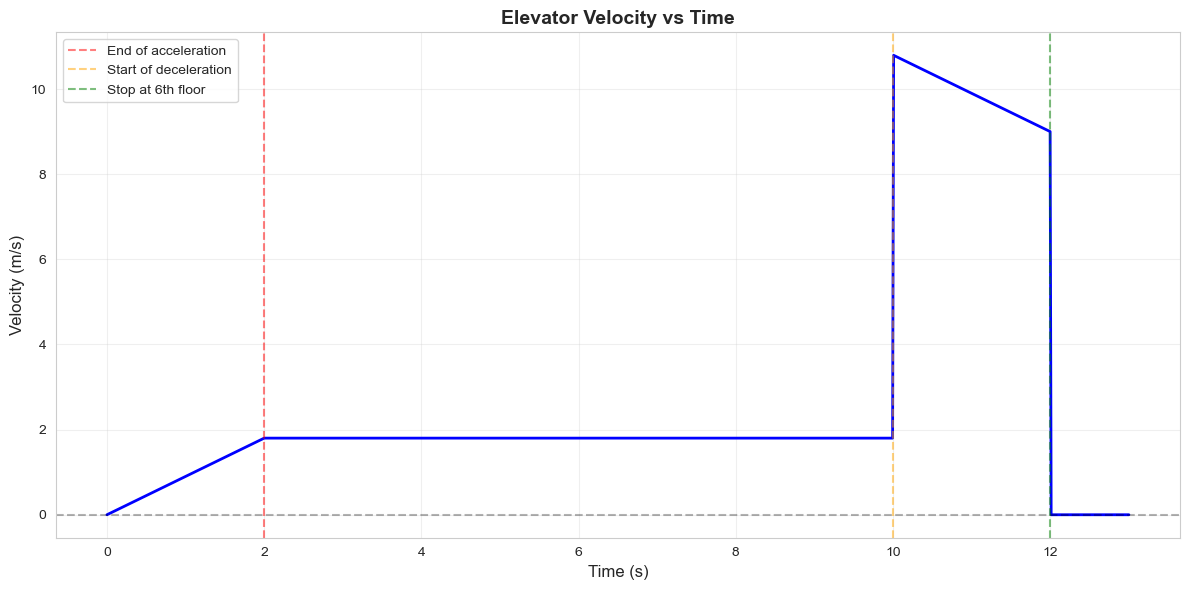


Velocity function with numerical values:


       ⎧   0.9⋅t      for t ≤ 2.0 
       ⎪                          
       ⎪    1.8       for t ≤ 10.0
v(t) = ⎨                          
       ⎪10.8 - 0.9⋅t  for t ≤ 12.0
       ⎪                          
       ⎩     0         otherwise  


Verification: Total distance = 18.00 m (should equal 18 m)


In [14]:
# Use realistic values for a 6-floor building scenario
# Let's assume: 6 floors, each 3m high = 18m total height
h_val = 18  # meters

# From acceleration equation: a = h/(5*T²), we need to choose a reasonable T
# Let's assume acceleration phase T = 2 seconds (reasonable for elevator)
T_val = 2.0  # seconds

# Calculate acceleration from equation
a_val = h_val / (5 * T_val**2)

print(f"Assumed values:")
print(f"h = {h_val} m (6 floors × 3m/floor)")
print(f"T = {T_val} s (acceleration phase duration)")
print(f"a = {a_val:.3f} m/s²")

# Create time array for plotting
t_array = np.linspace(0, 6*T_val + 1, 1000)  # Add extra time to show final stop

# Define velocity function numerically
def velocity_numeric(t_val):
    if t_val <= T_val:
        return a_val * t_val
    elif t_val <= 5 * T_val:
        return T_val * a_val
    elif t_val <= 6 * T_val:
        return 6 * T_val * a_val - a_val * (t_val - 5 * T_val)
    else:
        return 0

v_array = [velocity_numeric(t_val) for t_val in t_array]

# Create plot
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
plt.plot(t_array, v_array, linewidth=2, color='blue')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=T_val, color='red', linestyle='--', alpha=0.5, label='End of acceleration')
plt.axvline(x=5*T_val, color='orange', linestyle='--', alpha=0.5, label='Start of deceleration')
plt.axvline(x=6*T_val, color='green', linestyle='--', alpha=0.5, label='Stop at 6th floor')

plt.title('Elevator Velocity vs Time', fontsize=14, fontweight='bold')
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Velocity (m/s)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display piecewise function with numerical values
print("\nVelocity function with numerical values:")
v_numeric = sp.Piecewise(
    (a_val * t, t <= T_val), 
    (T_val * a_val, (t > T_val) & (t <= 5 * T_val)), 
    (6 * T_val * a_val - a_val * t, (t > 5 * T_val) & (t <= 6*T_val)),
    (0, t > 6*T_val)
)
display(sp.Eq(sp.Function("v")(t), v_numeric))

# Verify total height matches our assumption
# Stage 1: Distance during acceleration (0 to T)
d1 = a_val * T_val**2 / 2

# Stage 2: Distance during constant velocity (T to 5T)
# Duration = 5T - T = 4T, constant velocity = a*T
d2 = a_val * T_val * (5 * T_val - T_val)

# Stage 3: Distance during deceleration (5T to 6T)
# This is a triangular area under the deceleration line
# Initial velocity at 5T = a*T, final velocity at 6T = 0
# Distance = (initial velocity + final velocity) * time / 2
d3 = (a_val * T_val + 0) * (6 * T_val - 5 * T_val) / 2

# Total distance
total_distance = d1 + d2 + d3
print(f"\nVerification: Total distance = {total_distance:.2f} m (should equal {h_val} m)")

## Worked Examples

### WE 1.2

An apple is suspended a height $h$ above the ground. A physics demo instructor has set 
up a projectile gun a horizontal distance $d$ away from the apple. The projectile 
is initially a height $s$ above the ground. The demo instructor fires the projectile 
with an initial velocity of magnitude $v_0$ just as the apple is released. Find $\theta_0$, 
the angle at which the projectile gun must be aimed in order for the projectile 
to strike the apple. Ignore air resistance.

![Figure 1.2](../figures/WE0102.jpg)

In [15]:
# Bullet Kinematics

h, d, s, v0, theta0, g = sp.symbols("h d s v0 theta0 g", real=True, positive=True)
x, y = dynamicsymbols("x y")

# Simplify the time variable reference
t = dynamicsymbols._t 

values = {g: 9.81}

vecb_a = -g * N.y
vecb_r = x * N.x + y * N.y

# Extract the scalar differential equations from the matrix
bullet_matrix = (vecb_r.dt(N).dt(N) - vecb_a).to_matrix(N)
print("Acceleration matrix equation:")
display(sp.Eq(bullet_matrix, sp.zeros(3, 1)))

# Extract scalar equations (only x and y components are non-trivial)
xb_a_eq = sp.Eq(bullet_matrix[0], 0)  # ẍ = 0
yb_a_eq = sp.Eq(bullet_matrix[1], 0)  # ÿ + g = 0

print("\nBullet scalar differential equations:")
display(
    Math(
        f"{spv.vlatex(bullet_matrix[0])} = 0"
        + r",\;"
        + f"{spv.vlatex(bullet_matrix[1])} = 0"
    )
)

# Solve the differential equations using simplified time variable
print("\nSolving x-equation (ẍ = 0):")
xb_solution = sp.dsolve(
    xb_a_eq,
    ics={
        x.subs(t, 0): 0,
        x.diff(t).subs(t, 0): v0 * sp.cos(theta0),
    },
)
display(xb_solution)

print("\nSolving y-equation (ÿ + g = 0):")
yb_solution = sp.dsolve(
    yb_a_eq,
    ics={
        y.subs(t, 0): s,
        y.diff(t).subs(t, 0): v0 * sp.sin(theta0),
    },
)
display(yb_solution)

# Extract the solution functions
x_b = xb_solution.rhs
y_b = yb_solution.rhs

print("\nBullet final position vector:")
r_b = x_b * N.x + y_b * N.y
display(r_b)

Acceleration matrix equation:


⎡  ẍ  ⎤   ⎡0⎤
⎢     ⎥   ⎢ ⎥
⎢g + ÿ⎥ = ⎢0⎥
⎢     ⎥   ⎢ ⎥
⎣  0  ⎦   ⎣0⎦


Bullet scalar differential equations:


<IPython.core.display.Math object>


Solving x-equation (ẍ = 0):


x = t⋅v₀⋅cos(θ₀)


Solving y-equation (ÿ + g = 0):


         2                   
      g⋅t                    
y = - ──── + s + t⋅v₀⋅sin(θ₀)
       2                     


Bullet final position vector:


                   ⎛     2                   ⎞    
                   ⎜  g⋅t                    ⎟    
t⋅v₀⋅cos(θ₀) n_x + ⎜- ──── + s + t⋅v₀⋅sin(θ₀)⎟ n_y
                   ⎝   2                     ⎠    

In [16]:
# Apple kinematics

x, y = dynamicsymbols("x y")

veca_a = -g * N.y
veca_r = y * N.y

# Extract the scalar differential equations from the matrix
apple_matrix = (veca_r.dt(N).dt(N) - veca_a).to_matrix(N)
print("Apple acceleration matrix equation:")
display(sp.Eq(apple_matrix, sp.zeros(3, 1)))

# Extract scalar equations (only x and y components are non-trivial)
xa_a_eq = sp.Eq(apple_matrix[0], 0)  # ẍ = 0
ya_a_eq = sp.Eq(apple_matrix[1], 0)  # ÿ + g = 0

print("\nApple scalar differential equation, vertical motion:")
display(
    Math(
        f"{spv.vlatex(apple_matrix[1])} = 0"
    )
)

# Solve the differential equation susing simplified time variable
print("\nSolving y-equation (ÿ + g = 0):")
ya_solution = sp.dsolve(
    ya_a_eq,
    ics={
        y.subs(t, 0): h,
        y.diff(t).subs(t, 0): 0,
    },
)
display(ya_solution)

# Extract the solution functions
y_a = ya_solution.rhs

print("\nApple final position vector:")
r_a = y_a * N.y
display(r_a)

Apple acceleration matrix equation:


⎡  0  ⎤   ⎡0⎤
⎢     ⎥   ⎢ ⎥
⎢g + ÿ⎥ = ⎢0⎥
⎢     ⎥   ⎢ ⎥
⎣  0  ⎦   ⎣0⎦


Apple scalar differential equation, vertical motion:


<IPython.core.display.Math object>


Solving y-equation (ÿ + g = 0):


         2    
      g⋅t     
y = - ──── + h
       2      


Apple final position vector:


⎛     2    ⎞    
⎜  g⋅t     ⎟    
⎜- ──── + h⎟ n_y
⎝   2      ⎠    

In [17]:
# Compute the angle theta that determines that the bullet will hit the apple

# Calculate the time of flight to reach the apple
T = sp.solve(sp.Eq(r_b.dot(N.x), d), t, dict=True)[0]
display(T)

# Calculate the relative position in height(y)
print("Relative position in height(y):")
display(r_b.dot(N.y) - r_a.dot(N.y))

# Equate the y-components
print("Equate the y-components:")
eq1 = sp.Eq(r_b.dot(N.y) - r_a.dot(N.y), 0).subs(T).simplify()
display(eq1)

# Solve for theta
print("Solve for tan(theta):")
theta_solution = sp.solve(eq1, sp.tan(theta0))[0]

display(sp.atan(theta_solution).simplify())

⎧       d     ⎫
⎨t: ──────────⎬
⎩   v₀⋅cos(θ₀)⎭

Relative position in height(y):


-h + s + t⋅v₀⋅sin(θ₀)

Equate the y-components:


d⋅tan(θ₀) - h + s = 0

Solve for tan(theta):


    ⎛h - s⎞
atan⎜─────⎟
    ⎝  d  ⎠

### WE 1.5

You are in a car standing by a traffic light and at time $t=0$ the light turns green. 
You start to accelerate during the first $t_1$ seconds so that the acceleration of 
your car is given by:

$$
a_1(t) = 
\begin{cases} 
    b_1 & \text{for } 0 \leq t \leq t_1 \\
    0 & \text{for } t_1 \le t \leq t_2
\end{cases}
$$

where $b_1$ is a positive constant.

At the instant the light turns green a cyclist passes through the 
intersection moving with a speed $v_0$ in the same direction as your car is moving. 
At that instant, the cyclist starts to brake with a constant 
acceleration of magnitude $b_2$. At time $t=t_2$ the cyclist stops at the 
same location where you are.

The goal of the problem is to calculate the value of $b_2$ in terms of the given 
variables, $v_0$, $b_1$, $t_1$, and $t_2$.

First: Describe the motion of the car. Given the car’s acceleration $a_1(t)$, 
find its velocity and its position as a function of time:

(Part b) Calculate $x_1(t)$, the car’s position as a funcion of time. 
Express your answer in terms of $b_1$, $t_1$, and $t$ as needed.

Second: Describe the motion of the bicycle. Given the bicycle’s acceleration $a_2(t)$, 
find its velocity and its position:

(Part c) Calculate $v_2(t)$, the bicycle’s velocity as a funcion of time. 
Express your answer in terms of $v_0$, $b_2$, and $t$ as needed.

(Part d) Calculate $x_2(t)$, the bicycle’s position as a funcion of time. 
Express your answer in terms of $v_0$, $b_2$, and $t$ as needed.

Third: Find the value of $b_2$. We know that the bicycle stops at $t = t_2$, 
this condition is expressed as:

$$v_2(t_2) = 0$$

We also know that the bicycle and the car are at the same location when 
the bicycle stops. This condition implies:

$$
x_1(t_2) = x_2(t_2)
$$

Use (eq.1) and (eq. 2) to obtain the value of $b_2$. Express your answer in 
terms of $v_0$, $b_1$, $t_1$, and $t_2$. Do not use $b_2$ in your answer.

In [18]:
# b. Kinematics of car

# Define symbols
b1, t1, t2 = sp.symbols("b1 t1 t2", real=True, positive=True)
t = sp.symbols("t", real=True)

# Create piecewise acceleration function
a_1 = sp.Piecewise((b1, (t >= 0) & (t <= t1)), (0, (t >= t1) & (t <= t2)))

print("Piecewise acceleration function a_1(t):")
display(Math(r"a_1(t) = " + sp.latex(a_1)))

print("\n=== Solving with dsolve for each interval ===")

# Interval 1: 0 ≤ t ≤ t1 (acceleration = b1)
x11 = sp.Function("x_11")(t)

x11_solution = sp.dsolve(
    sp.Eq(sp.diff(x11, t, t), b1),
    ics={x11.subs(t, 0): 0, sp.diff(x11, t).subs(t, 0): 0},
)
display(x11_solution)

# Interval 2: t1 ≤ t ≤ t2 (acceleration = 0)
x12 = sp.Function("x_12")(t)

x12_solution = sp.dsolve(
    sp.Eq(sp.diff(x12, t, t), 0),
    ics={
        x12.subs(t, t1): x11_solution.rhs.subs(t, t1),
        sp.diff(x12, t).subs(t, t1): sp.diff(x11_solution.rhs, t).subs(t, t1),
    },
)
display(x12_solution)

x1 = sp.Piecewise(
    (x11_solution.rhs, (t >= 0) & (t <= t1)), (x12_solution.rhs, (t >= t1) & (t <= t2))
)
print("Part b:")
display(sp.Eq(sp.Function("x_1")(t), x1))

Piecewise acceleration function a_1(t):


<IPython.core.display.Math object>


=== Solving with dsolve for each interval ===


             2
         b₁⋅t 
x₁₁(t) = ─────
           2  

                        2
                   b₁⋅t₁ 
x₁₂(t) = b₁⋅t⋅t₁ - ──────
                     2   

Part b:


        ⎧         2                           
        ⎪     b₁⋅t                            
        ⎪     ─────        for t ≥ 0 ∧ t ≤ t₁ 
        ⎪       2                             
x₁(t) = ⎨                                     
        ⎪               2                     
        ⎪          b₁⋅t₁                      
        ⎪b₁⋅t⋅t₁ - ──────  for t ≥ t₁ ∧ t ≤ t₂
        ⎩            2                        

In [19]:
# c. Kinematics of Bicycle

v_0, b_2 = sp.symbols("v_0 b2", real=True, positive=True)

x2 = sp.Function("x_2")(t)
eq_b = sp.Eq(x2.diff(t, t), -b_2)

x2_solution = sp.dsolve(eq_b, x2, 
    ics={x2.subs(t, 0): 0, x2.diff(t).subs(t, 0): v_0}
)

display(x2_solution)

print("Part c:")
display(sp.Eq(sp.Function("v_2")(t), x2_solution.rhs.diff(t)))

print("Part d:")
display(sp.Eq(sp.Function("x_2")(t), x2_solution.rhs))

              2       
          b₂⋅t        
x₂(t) = - ───── + t⋅v₀
            2         

Part c:


v₂(t) = -b₂⋅t + v₀

Part d:


              2       
          b₂⋅t        
x₂(t) = - ───── + t⋅v₀
            2         

In [20]:
# Third: Find the value of b_2

# Extract velocity function from bicycle position solution
v2 = x2_solution.rhs.diff(t)
display(sp.Eq(sp.Function('v')(t), v2))

# Condition 1: Bicycle stops at t = t2 (eq.1)
# Set velocity equal to zero at time t2
eq1 = sp.Eq(v2.subs(t, t2), 0)
display(sp.Eq(sp.Function('v')(t2), eq1.rhs))

# Condition 2: Bicycle and car are at same location when bicycle stops (eq.2)
# Set car position (interval 2) equal to bicycle position at time t2
eq2 = sp.Eq(x12_solution.rhs.subs(t, t2), x2_solution.rhs.subs(t, t2))

# Solve the system of equations for t2 and b_2
# eq1 gives us t2 in terms of b_2 and v_0
# eq2 gives us the relationship between positions
solution = sp.solve([eq1, eq2], [t2, b_2])

# Display the final expression for b_2 in terms of given variables
display(sp.Eq(sp.Symbol('b_2'), solution[0][1].simplify()))

v(t) = -b₂⋅t + v₀

v(t₂) = 0

     v₀⋅(2⋅b₁⋅t₁ - v₀)
b₂ = ─────────────────
               2      
          b₁⋅t₁       